# Week 3

Remove instrumental systematics; understand CBVs, SFF, and basic sigma-clipping.

A detrended light curve of V1298 Tau (TIC 264461976) from at least 2 TESS sectors, with a documented justification of which detrending method was chosen and why (CBV vs. Wotan biweight). Include before/after comparison plots.

In [1]:
# Import libraries
%matplotlib inline

from lightkurve import search_targetpixelfile, search_lightcurve
import matplotlib.pyplot as plt
import numpy as np

/Users/csavva/Documents/Repositories/astro-research/.venv/lib/python3.12/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


---
## 1. Download the SPOC light curves

We search MAST for 2-minute cadence SPOC products for V1298 Tau (TIC 264461976) and download all available sectors.

In [2]:
TIC_ID = 'TIC 264461976'

# Search and display what's available
search_result = search_lightcurve(TIC_ID, author='SPOC', cadence=120)
print(search_result)
print()

SearchResult containing 2 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 06 2018   SPOC     120   264461976      0.0
  1 TESS Sector 32 2020   SPOC     120   264461976      0.0



In [3]:
# Download the first two sectors
lc_1 = search_result[0].download()
lc_2 = search_result[1].download()

print(f'LC : {lc_1.mission}  sector {lc_1.sector}  shape {lc_1.flux.shape}')
print(f'LC : {lc_2.mission}  sector {lc_2.sector}  shape {lc_2.flux.shape}')


LC : TESS  sector 6  shape (14679,)
LC : TESS  sector 32  shape (17906,)


---
## 2. Apply quality bitmask filtering

bits 1, 2, 4, and 8 flag the most problematic cadences (attitude tweaks, safe mode, coarse point, cosmic ray in optimal aperture). Remove those cadences. Initially tried filtering only bits 1, 2, 4, and 8, but these specific flags weren't present in either sector. Inspecting the actual quality values revealed that the flagged cadences use higher bits (e.g. straylight, impulsive outliers). Switched to removing all cadences with any quality flag set (`quality == 0`).

In [4]:
# Filter all flagged cadences (quality == 0 means no flags set)
lc_1_clean = lc_1[lc_1.quality == 0]
lc_2_clean = lc_2[lc_2.quality == 0]

print(f'Sector 6:  {len(lc_1)} -> {len(lc_1_clean)} cadences ({len(lc_1) - len(lc_1_clean)} removed)')
print(f'Sector 32: {len(lc_2)} -> {len(lc_2_clean)} cadences ({len(lc_2) - len(lc_2_clean)} removed)')

Sector 6:  14679 -> 14610 cadences (69 removed)
Sector 32: 17906 -> 17013 cadences (893 removed)


---
## 3. Compare raw SAP vs. PDCSAP flux

SAP (Simple Aperture Photometry) is the raw summed flux from the aperture, containing both astrophysical signal and instrumental systematics. PDCSAP (Pre-search Data Conditioning SAP) is the SPOC pipeline's attempt to remove systematics using cotrending basis vectors. Comparing the two shows what the pipeline corrects and where it may over- or under-correct.

For V1298 Tau, the dominant signal is the ~2.87-day stellar rotation from starspots — this is real and should be preserved. We expect SAP and PDCSAP to look similar for this target since the stellar variability dominates over instrumental trends.

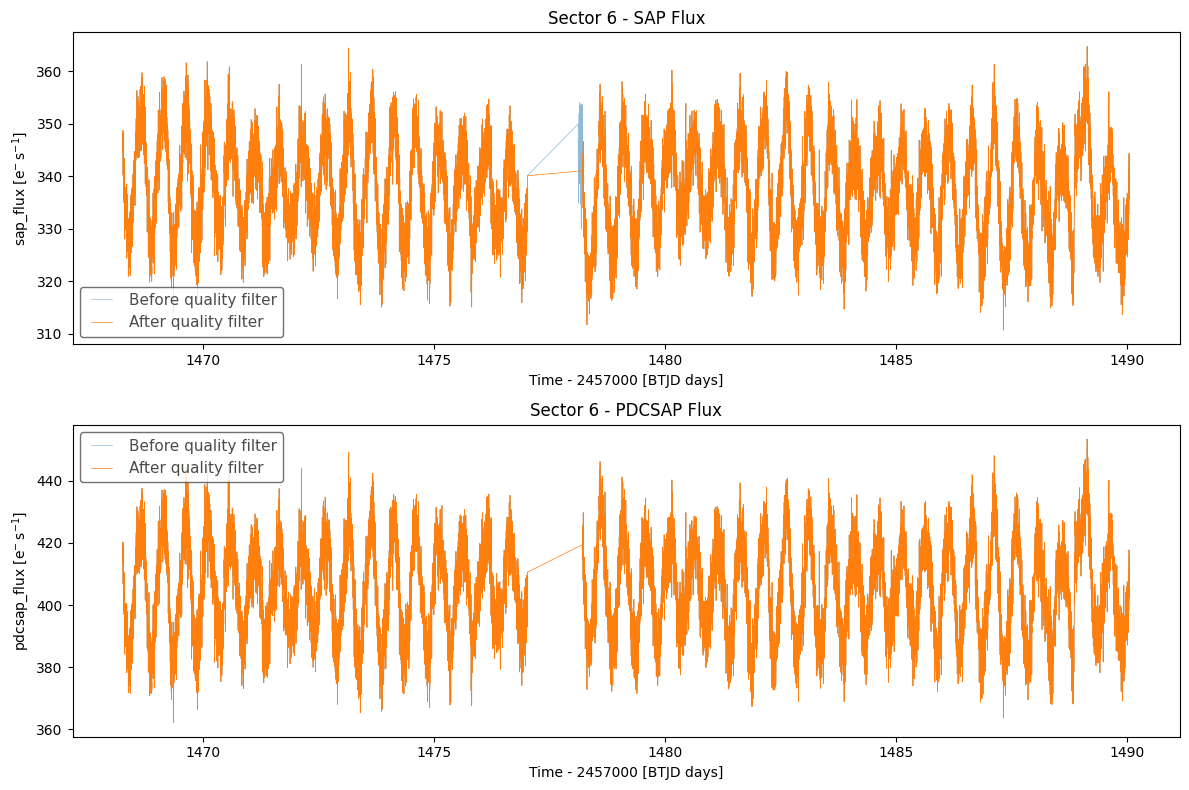

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
lc_1.normalize().plot(column='sap_flux', ax=ax1, label='Before quality filter', alpha=0.5)
lc_1_clean.normalize().plot(column='sap_flux', ax=ax1, label='After quality filter')
ax1.set_title('Sector 6 - SAP Flux')

lc_1.normalize().plot(column='pdcsap_flux', ax=ax2, label='Before quality filter', alpha=0.5)
lc_1_clean.normalize().plot(column='pdcsap_flux', ax=ax2, label='After quality filter')
ax2.set_title('Sector 6 - PDCSAP Flux')
plt.tight_layout()

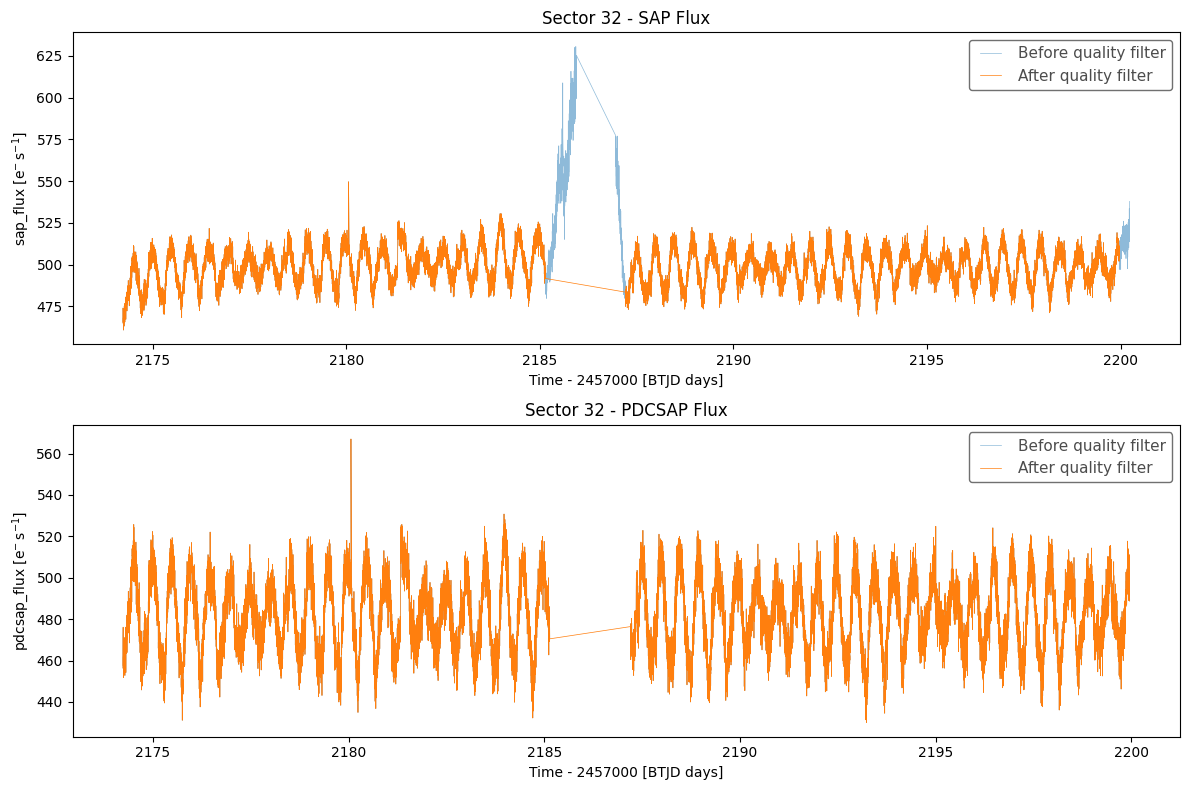

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
lc_2.normalize().plot(column='sap_flux', ax=ax1, label='Before quality filter', alpha=0.5)
lc_2_clean.normalize().plot(column='sap_flux', ax=ax1, label='After quality filter')
ax1.set_title('Sector 32 - SAP Flux')

lc_2.normalize().plot(column='pdcsap_flux', ax=ax2, label='Before quality filter', alpha=0.5)
lc_2_clean.normalize().plot(column='pdcsap_flux', ax=ax2, label='After quality filter')
ax2.set_title('Sector 32 - PDCSAP Flux')
plt.tight_layout()


---
## 4. Flatten experimentation

Lightkurve's `flatten()` applies a Savitzky-Golay filter with a sliding polynomial window. The `window_length` parameter (in cadences) controls how aggressive the detrending is:

- **Short windows** (e.g. 101 cadences ≈ 3.4 hours) track rapid variations tightly, removing real stellar variability and potentially distorting transit depths.
- **Long windows** (e.g. 1001 cadences ≈ 33 hours) only capture slow drifts, preserving transits and stellar rotation but leaving more systematics.

The goal is to observe this trade-off and understand why `flatten()` alone may not be ideal for a young, active star like V1298 Tau.

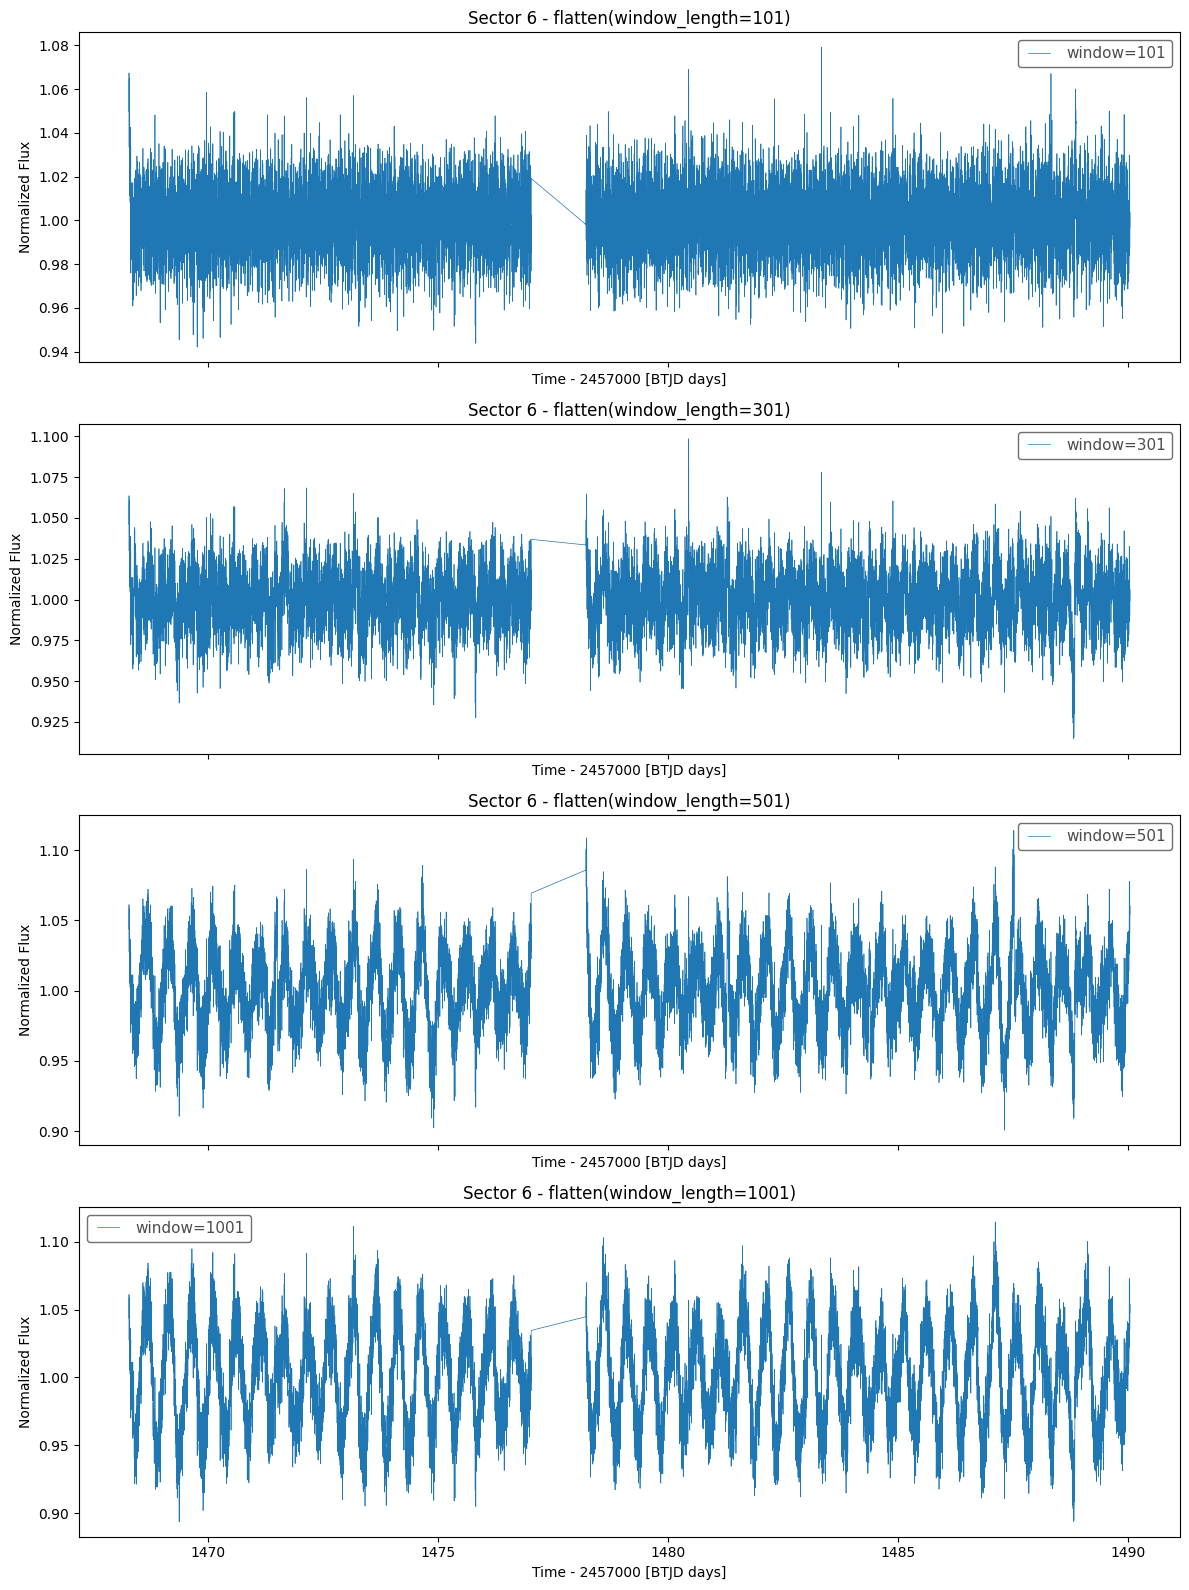

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)
windows = [101, 301, 501, 1001]

for ax, wl in zip(axes, windows):
    lc_1_clean.normalize().flatten(window_length=wl).plot(ax=ax, label=f'window={wl}')
    ax.set_title(f'Sector 6 - flatten(window_length={wl})')

plt.tight_layout()

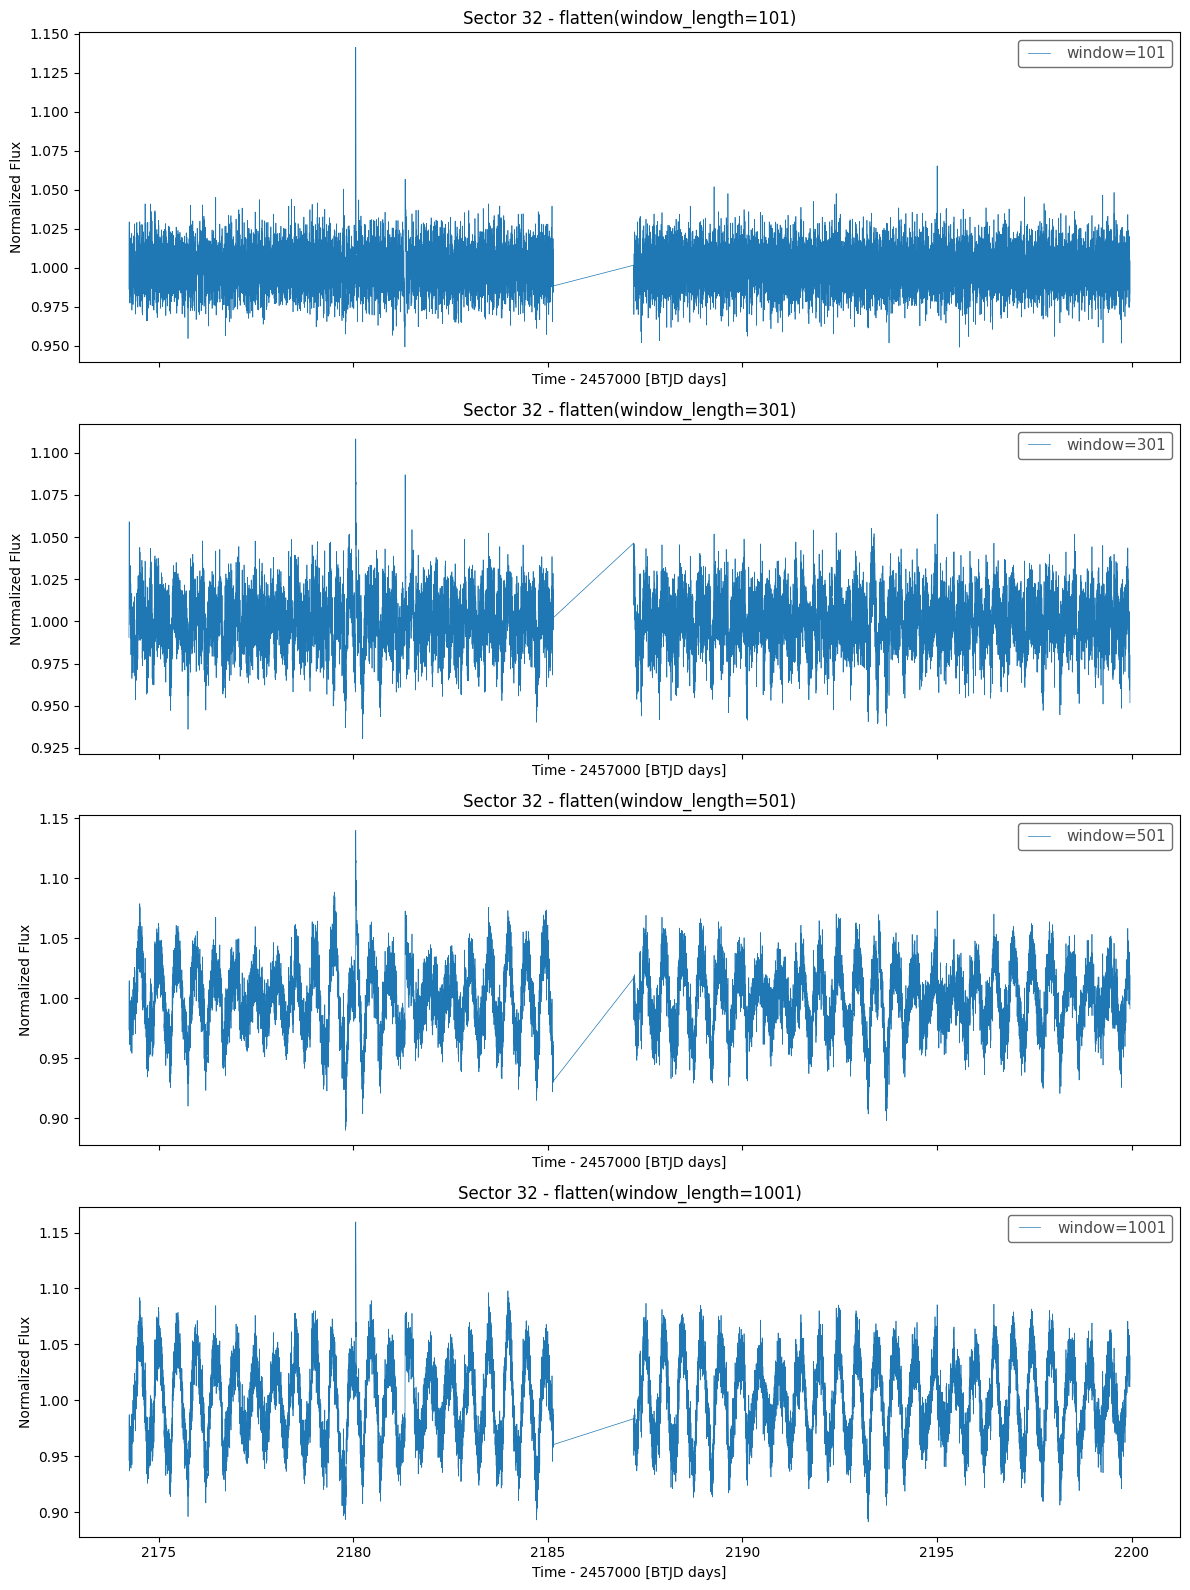

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)
windows = [101, 301, 501, 1001]

for ax, wl in zip(axes, windows):
    lc_2_clean.normalize().flatten(window_length=wl).plot(ax=ax, label=f'window={wl}')
    ax.set_title(f'Sector 32 - flatten(window_length={wl})')

plt.tight_layout()

---

## 5. CBVCorrector
Apply Lightkurve's CBVCorrector to the cleaned SAP flux. Experiment with the number of CBV components. Compare the result against PDCSAP — since PDCSAP is essentially the pipeline's own CBV correction, they should look similar but not identical.

In [9]:
from lightkurve.correctors import CBVCorrector
import lightkurve as lk

cbv_lc_1 = search_lightcurve(TIC_ID, author='SPOC', sector=6).download(flux_column='sap_flux')
print(f'Camera: {cbv_lc_1.camera}, CCD: {cbv_lc_1.ccd}')

try:
    cbvCorrector_1 = CBVCorrector(cbv_lc_1)
    print(cbvCorrector_1.cbvs)
except Exception as e:
    print(f"Error: {e}")

cbv_lc_2 = search_lightcurve(TIC_ID, author='SPOC', sector=32).download(flux_column='sap_flux')
print(f'Camera: {cbv_lc_2.camera}, CCD: {cbv_lc_2.ccd}')

try:
    cbvCorrector_2 = CBVCorrector(cbv_lc_2)
    print(cbvCorrector_2.cbvs)
except Exception as e:
    print(f"Error: {e}")


Camera: 1, CCD: 1
Error: CBVS were not found
Camera: 1, CCD: 2
Error: CBVS were not found


CBVs were not available on MAST for either Sector 6 (Camera 1, CCD 1) or Sector 32 (Camera 1, CCD 2). This rules out CBVCorrector as a detrending option for this target.

We proceed with Wotan's biweight filter, which is better suited to V1298 Tau regardless — its robust location estimator naturally handles outliers like transit dips and flares without being pulled toward them, unlike the Savitzky-Golay filter used by `flatten()`.

---

## 6. Wotan biweight filter

Apply Wotan's biweight filter to the same SAP flux. Compare the result to the flatten() output.

In [10]:
from wotan import flatten

In [11]:
flatten_lc_1, trend_lc_1 = flatten(lc_1_clean.time.value, lc_1_clean.flux.value, window_length=1.6, method='biweight', return_trend=True)

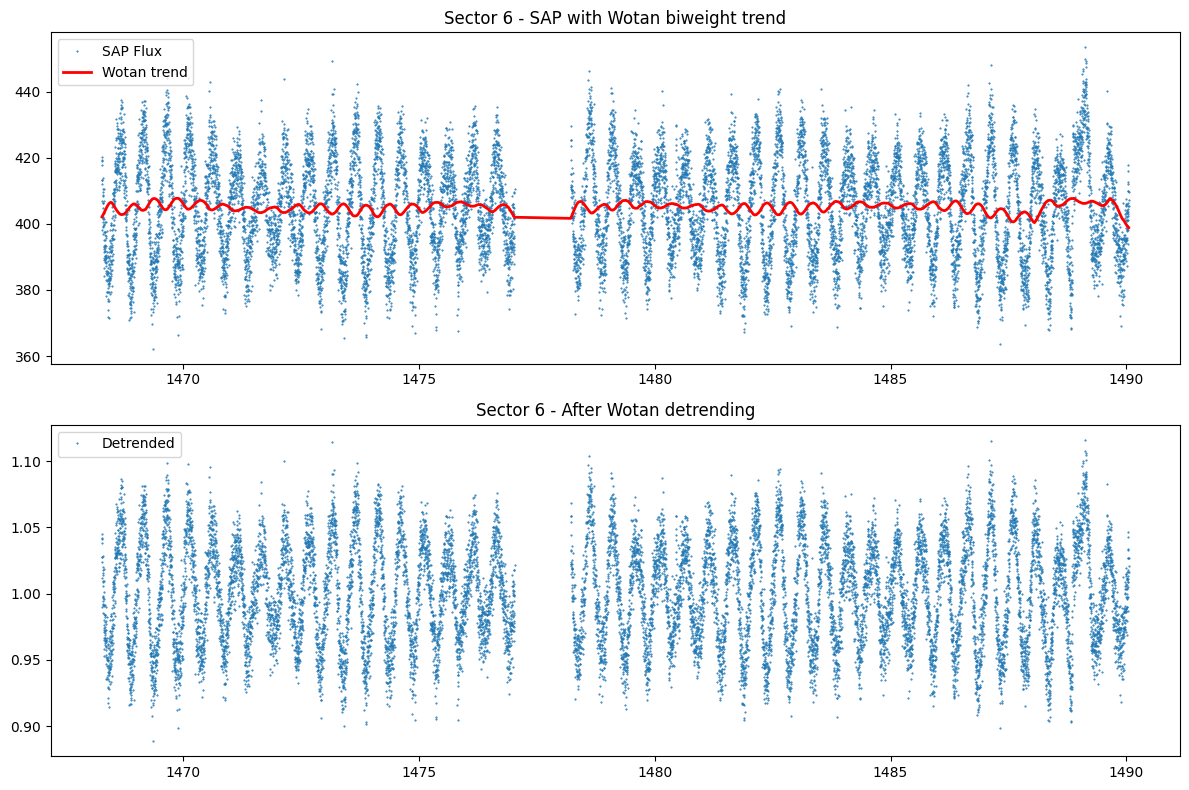

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
ax1.plot(lc_1_clean.time.value, lc_1_clean.flux.value, '.', ms=1, label='SAP Flux')
ax1.plot(lc_1_clean.time.value, trend_lc_1, 'r-', lw=2, label='Wotan trend')
ax1.set_title('Sector 6 - SAP with Wotan biweight trend')
ax1.legend()

ax2.plot(lc_1_clean.time.value, flatten_lc_1, '.', ms=1, label='Detrended')
ax2.set_title('Sector 6 - After Wotan detrending')
ax2.legend()
plt.tight_layout()

In [13]:
flatten_lc_2, trend_lc_2 = flatten(lc_2_clean.time.value, lc_2_clean.flux.value, window_length=1.6, method='biweight', return_trend=True)

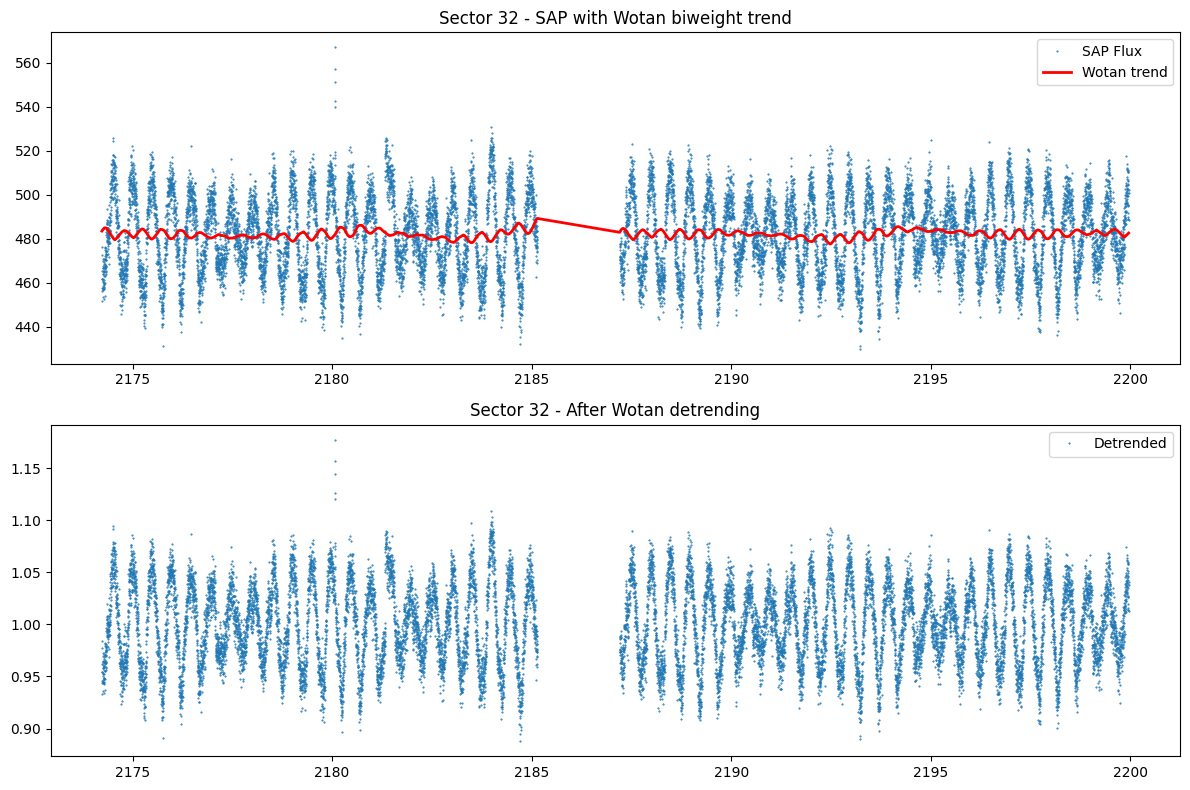

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
ax1.plot(lc_2_clean.time.value, lc_2_clean.flux.value, '.', ms=1, label='SAP Flux')
ax1.plot(lc_2_clean.time.value, trend_lc_2, 'r-', lw=2, label='Wotan trend')
ax1.set_title('Sector 32 - SAP with Wotan biweight trend')
ax1.legend()

ax2.plot(lc_2_clean.time.value, flatten_lc_2, '.', ms=1, label='Detrended')
ax2.set_title('Sector 32 - After Wotan detrending')
ax2.legend()
plt.tight_layout()

---

## 7. Sigma-clipping

Apply `astropy.stats.sigma_clip()` at 3σ to remove remaining instrumental outliers (cosmic rays, residual glitches) from the detrended light curves. Using 3σ rather than a more aggressive threshold (e.g. 2σ) is deliberate — V1298 Tau has known planetary transits that produce real flux dips, and too-aggressive clipping would remove genuine transit points.

In [15]:
from astropy.stats import sigma_clip

flux_clipped_1 = sigma_clip(flatten_lc_1, sigma=3)
flux_clipped_2 = sigma_clip(flatten_lc_2, sigma=3)

mask_1 = ~flux_clipped_1.mask
mask_2 = ~flux_clipped_2.mask

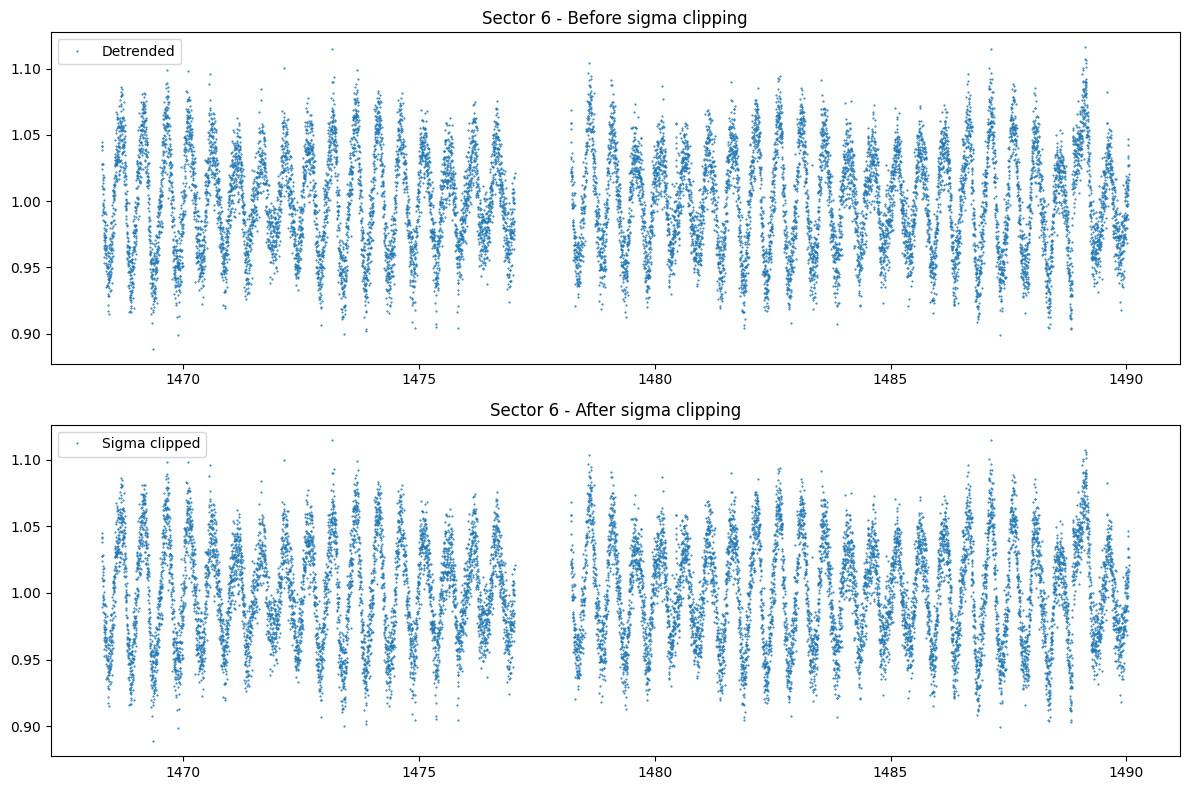

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
ax1.plot(lc_1_clean.time.value, flatten_lc_1, '.', ms=1, label='Detrended')
ax1.set_title('Sector 6 - Before sigma clipping')
ax1.legend()

ax2.plot(lc_1_clean.time.value[mask_1], flatten_lc_1[mask_1], '.', ms=1, label='Sigma clipped')
ax2.set_title('Sector 6 - After sigma clipping')
ax2.legend()
plt.tight_layout()

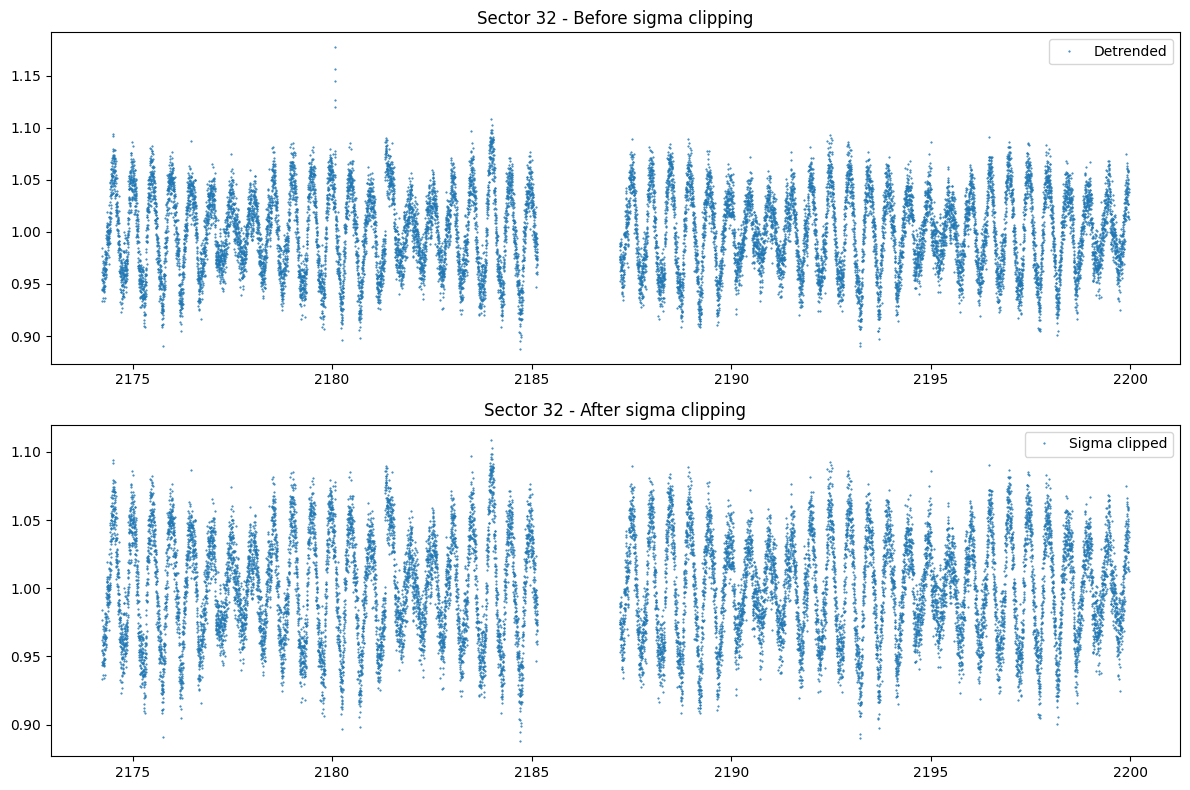

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
ax1.plot(lc_2_clean.time.value, flatten_lc_2, '.', ms=1, label='Detrended')
ax1.set_title('Sector 32 - Before sigma clipping')
ax1.legend()

ax2.plot(lc_2_clean.time.value[mask_2], flatten_lc_2[mask_2], '.', ms=1, label='Sigma clipped')
ax2.set_title('Sector 32 - After sigma clipping')
ax2.legend()
plt.tight_layout()

---

## Summary & Method Justification

### Target characteristics
V1298 Tau is a young (~23 Myr) pre-main-sequence K-type star with known transiting planets (David et al. 2019). Its youth means strong starspot modulation with a rotation period of ~2.87 days, producing peak-to-peak variability of several percent. Any detrending method must handle three overlapping signals: instrumental systematics, stellar rotation, and planetary transits.

### Methods evaluated

**Quality filtering:** Removed all cadences with non-zero quality flags. This eliminated 69 cadences in Sector 6 (mostly near the data gap) and 893 in Sector 32 (primarily scattered light contamination near BTJD 2185). Initial attempt with bits 1|2|4|8 caught nothing — the actual flags present were higher-order bits (straylight, impulsive outliers).

**Lightkurve `flatten()`:** Tested window lengths from 101 to 1001 cadences. Short windows aggressively removed the rotational variability and distorted transit shapes. Longer windows preserved more signal but the Savitzky-Golay filter is not robust to outliers — transit dips and flares pull the trend estimate toward them, biasing the baseline.

**CBVCorrector:** Not available — CBV files were missing from MAST for both sectors.

**Wotan biweight (chosen method):** Applied with a window length of 1.6 days. The biweight location estimator is inherently robust to outliers, meaning transit dips and flares do not distort the trend estimate. The 1.6-day window is approximately half the stellar rotation period, long enough to bridge over transits (which last a few hours) while following the broader instrumental baseline. This preserves both transit depth fidelity and the rotational modulation envelope.

**Sigma-clipping:** Applied at 3σ after Wotan detrending to remove residual instrumental outliers without clipping genuine transit points.

### Final pipeline
`Quality filter (quality == 0)` → `Wotan biweight (window = 1.6 d)` → `3σ sigma-clip`

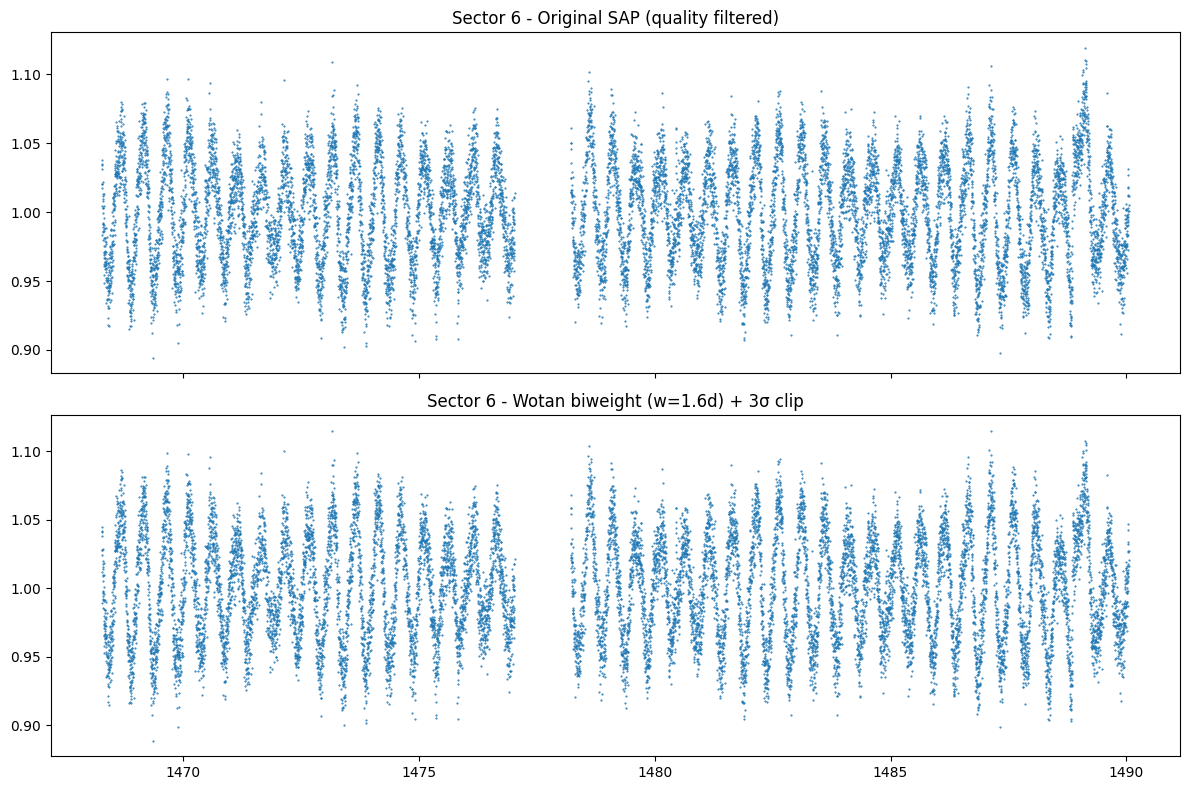

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(lc_1_clean.time.value, lc_1_clean.normalize().flux.value, '.', ms=1)
ax1.set_title('Sector 6 - Original SAP (quality filtered)')
ax2.plot(lc_1_clean.time.value[mask_1], flatten_lc_1[mask_1], '.', ms=1)
ax2.set_title('Sector 6 - Wotan biweight (w=1.6d) + 3σ clip')
plt.tight_layout()

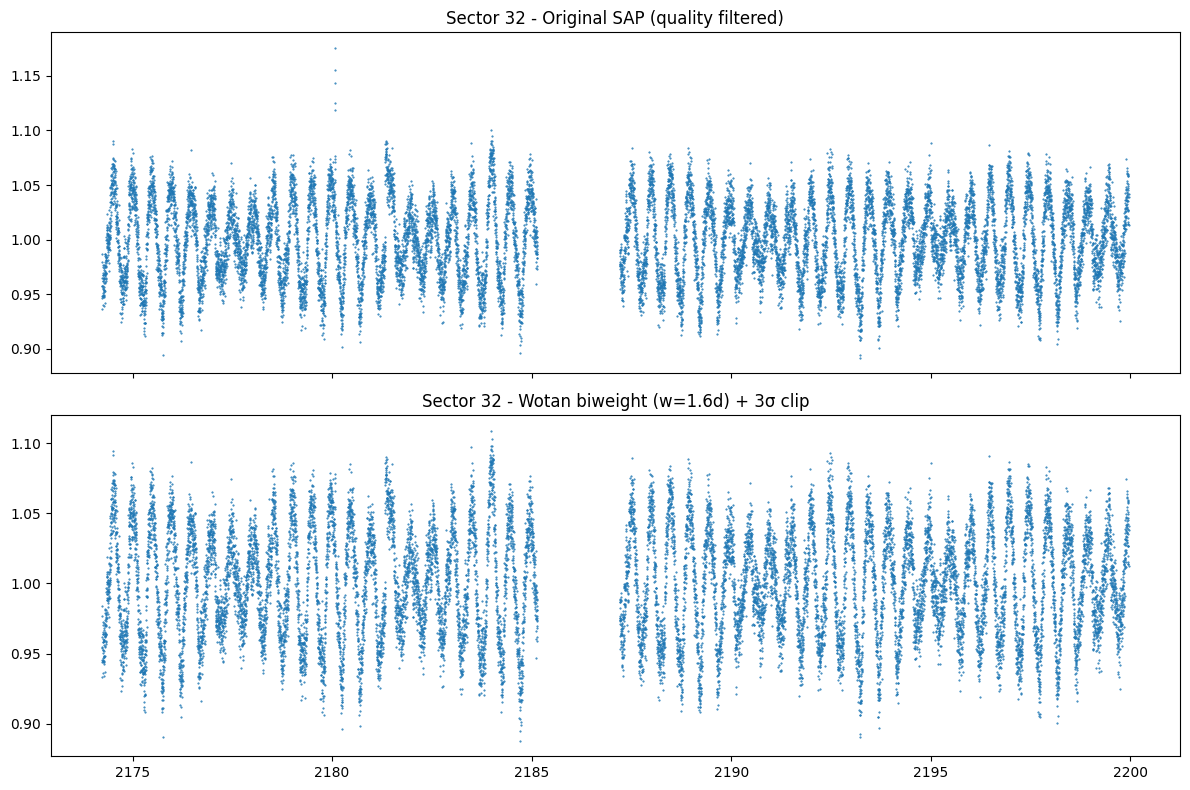

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(lc_2_clean.time.value, lc_2_clean.normalize().flux.value, '.', ms=1)
ax1.set_title('Sector 32 - Original SAP (quality filtered)')
ax2.plot(lc_2_clean.time.value[mask_2], flatten_lc_2[mask_2], '.', ms=1)
ax2.set_title('Sector 32 - Wotan biweight (w=1.6d) + 3σ clip')
plt.tight_layout()